In [8]:
import os
import librosa
import soundfile as sf

# ------------------------------
# Settings
# ------------------------------
input_dir = "/automathon/users/mig_user3/Automathon_Sujet/dataset/bird_songs"
output_dir = "/automathon/users/mig_user3/Automathon_Sujet/dataset/processed_bird_songs"
target_sr = 22050       # Hz

os.makedirs(output_dir, exist_ok=True)

# ------------------------------
# Process each species folder
# ------------------------------
for species in os.listdir(input_dir):
    species_path = os.path.join(input_dir, species)
    if not os.path.isdir(species_path):
        continue
    
    out_species_dir = os.path.join(output_dir, species)
    os.makedirs(out_species_dir, exist_ok=True)
    
    for filename in os.listdir(species_path):
        if filename.endswith(".ogg"):
            file_path = os.path.join(species_path, filename)
            out_file = os.path.join(out_species_dir, os.path.splitext(filename)[0] + ".wav")
            
            # Load ogg using librosa (no ffmpeg needed)
            y, sr = librosa.load(file_path, sr=target_sr)  # resample
            
            # Save as wav keeping original/adaptive length
            sf.write(out_file, y, target_sr)

print("All species processed successfully with adaptive lengths.")


All species processed successfully with adaptive lengths.


In [53]:
import os
import librosa
import soundfile as sf
import numpy as np
import matplotlib.pyplot as plt
import noisereduce as nr
from scipy.signal import butter, filtfilt
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm

# ============================================================
# CONFIGURATION
# ============================================================
DATASET_DIR = "/automathon/users/mig_user3/Automathon_Sujet/dataset/processed_bird_songs"
OUTPUT_DIR = "/automathon/users/mig_user3/Automathon_Sujet/dataset/cleaned_bird_songs"

SAMPLE_RATE = 22050            # Resample target sampling rate
HP_CUTOFF = 200.0              # High-pass cutoff (Hz); set 0 to disable
PROP_DECREASE = 0.75            # Denoising aggressiveness (0-1)
N_FFT = 2048
HOP_LENGTH = 512
VISUALIZE = False              # True = show pre/post spectrograms
N_JOBS = 4                     # Number of parallel processes
# ============================================================


# ------------------------------------------------------------
# 1. Signal utilities
# ------------------------------------------------------------
def highpass(signal, sr, cutoff=200.0, order=4):
    """Apply a Butterworth high-pass filter."""
    if cutoff <= 0:
        return signal
    b, a = butter(order, cutoff / (sr / 2), btype="highpass")
    return filtfilt(b, a, signal)


def normalize_rms(signal, target_dbfs=-20.0):
    """Normalize audio to target RMS (in dBFS)."""
    rms = np.sqrt(np.mean(signal**2))
    if rms == 0:
        return signal
    scalar = 10 ** (target_dbfs / 20) / rms
    return signal * scalar


def estimate_noise(y, sr):
    """Estimate noise clip using lowest-energy 2% of frames."""
    frame_len = sr // 10  # 0.1 sec window
    energy = np.convolve(y**2, np.ones(frame_len), mode="same")
    n = len(energy)
    low_idx = np.argpartition(energy, int(0.02 * n))[: int(0.02 * n)]
    start, end = low_idx.min(), low_idx.max()
    return y[start:end]


def plot_spectrograms(y_orig, y_clean, sr, title):
    """Display before/after Mel-spectrograms."""
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    S1 = librosa.power_to_db(librosa.feature.melspectrogram(y_orig, sr=sr), ref=np.max)
    S2 = librosa.power_to_db(librosa.feature.melspectrogram(y_clean, sr=sr), ref=np.max)
    img1 = librosa.display.specshow(S1, sr=sr, x_axis="time", y_axis="mel", ax=ax[0])
    img2 = librosa.display.specshow(S2, sr=sr, x_axis="time", y_axis="mel", ax=ax[1])
    ax[0].set_title("Original")
    ax[1].set_title("Cleaned")
    plt.suptitle(title)
    plt.show()


# ------------------------------------------------------------
# 2. Main processing per file
# ------------------------------------------------------------
def process_audio_file(input_path, output_path):
    """Load, filter, denoise, and save one file."""
    try:
        y, _ = librosa.load(input_path, sr=SAMPLE_RATE)
        y = highpass(y, SAMPLE_RATE, cutoff=HP_CUTOFF)
        pre_rms = np.sqrt(np.mean(y**2))

        # --- Noise reduction ---
        noise_clip = estimate_noise(y, SAMPLE_RATE)
        y_denoised = nr.reduce_noise(
            y=y,
            sr=SAMPLE_RATE,
            y_noise=noise_clip,
            prop_decrease=PROP_DECREASE,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH
        )

        # --- Adjust RMS to roughly match original ---
        denoised_rms = np.sqrt(np.mean(y_denoised**2))
        if denoised_rms > 0:
            y_denoised = y_denoised * (pre_rms / denoised_rms)

        # Ensure directory exists
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        sf.write(output_path, y_denoised, SAMPLE_RATE)

        if VISUALIZE:
            plot_spectrograms(y, y_denoised, SAMPLE_RATE, os.path.basename(input_path))

    except Exception as e:
        print(f"[ERROR] {input_path}: {e}")


# ------------------------------------------------------------
# 3. Directory traversal
# ------------------------------------------------------------
def get_audio_files(root_dir):
    """Yield full paths of .wav files under directory."""
    for subdir, _, files in os.walk(root_dir):
        for f in files:
            if f.lower().endswith(".wav"):
                yield os.path.join(subdir, f)


def build_output_path(input_path):
    """Mirror input directory structure in OUTPUT_DIR."""
    rel_path = os.path.relpath(input_path, DATASET_DIR)
    return os.path.join(OUTPUT_DIR, rel_path)

from functools import partial

def process_wrapper(task):
    """Unpack (input, output) tuple for multiprocessing."""
    input_path, output_path = task
    process_audio_file(input_path, output_path)

def main():
    audio_files = list(get_audio_files(DATASET_DIR))
    print(f"Found {len(audio_files)} audio files to process.")
    tasks = [(f, build_output_path(f)) for f in audio_files]

    if N_JOBS > 1:
        with ProcessPoolExecutor(max_workers=N_JOBS) as executor:
            list(tqdm(executor.map(process_wrapper, tasks), total=len(tasks)))
    else:
        for t in tqdm(tasks):
            process_wrapper(t)

    print("✅ Preprocessing complete.")
    print(f"Cleaned files saved in: {OUTPUT_DIR}")


if __name__ == "__main__":
    main()


Found 3952 audio files to process.


100%|██████████| 3952/3952 [15:22<00:00,  4.29it/s]  

✅ Preprocessing complete.
Cleaned files saved in: /automathon/users/mig_user3/Automathon_Sujet/dataset/cleaned_bird_songs


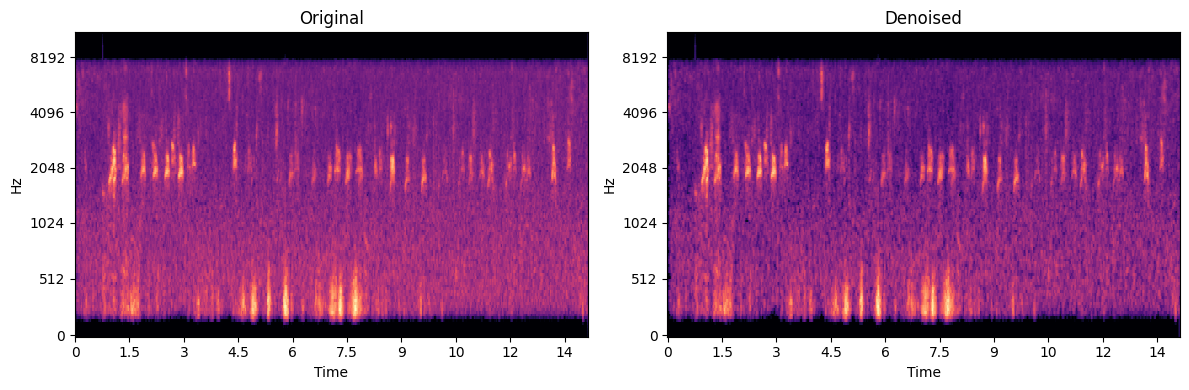

Processed 95 segments saved to /automathon/users/mig_user3/Automathon_Sujet/dataset/samplee_bird_clean.npy


In [1]:
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, medfilt

# ================= CONFIG =================
AUDIO_PATH = "/automathon/users/mig_user3/Automathon_Sujet/dataset/cleaned_bird_songs/#eubeat1/XC56698.wav"
OUTPUT_FILE = "/automathon/users/mig_user3/Automathon_Sujet/dataset/samplee_bird_clean.npy"
SAMPLE_RATE = 22050
HP_CUTOFF = 200.0          # High-pass filter cutoff
QUANTILE = 0.1             # alpha for quantile noise estimation
MEDIAN_KERNEL = 5          # median filter kernel size for smoothing
SILENCE_WINDOW = 1024      # frames for envelope calculation
SILENCE_THRESH = 0.01      # threshold for silence detection
SEGMENT_LENGTH_SEC = 1.0   # segment duration after silence removal
VISUALIZE = True
# ==========================================

# ---------------- High-pass filter ----------------
def highpass(signal, sr, cutoff=HP_CUTOFF, order=4):
    if cutoff <= 0:
        return signal
    b, a = butter(order, cutoff/(sr/2), btype='highpass')
    return filtfilt(b, a, signal)

# ---------------- Quantile-based spectral subtraction ----------------
def quantile_denoise(y, n_fft=2048, hop_length=512, quantile=QUANTILE, median_kernel=MEDIAN_KERNEL):
    # STFT
    S = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)
    magnitude, phase = np.abs(S), np.angle(S)
    
    # Quantile noise estimation per frequency bin
    noise_est = np.quantile(magnitude, quantile, axis=1)
    noise_est = medfilt(noise_est, kernel_size=median_kernel)[:, None]  # smooth across frames
    
    # Apply spectral subtraction
    S_clean_mag = np.maximum(magnitude - noise_est, 0.0)
    
    # Reconstruct signal with original phase
    S_clean = S_clean_mag * np.exp(1j * phase)
    y_clean = librosa.istft(S_clean, hop_length=hop_length)
    return y_clean, magnitude, S_clean_mag

# ---------------- Silence detection ----------------
def detect_silence(y, window_len=SILENCE_WINDOW, threshold=SILENCE_THRESH):
    y_abs = np.abs(y)
    envelope = np.convolve(y_abs, np.ones(window_len)/window_len, mode='same')
    mask = envelope > threshold
    return mask

# ---------------- Segmenting ----------------
def segment_audio(y, mask, sr, segment_length_sec=SEGMENT_LENGTH_SEC):
    segments = []
    current = []
    for i, keep in enumerate(mask):
        if keep:
            current.append(y[i])
        elif current:
            segments.append(np.array(current))
            current = []
    if current:
        segments.append(np.array(current))
    
    # Split long segments into fixed-length
    final_segments = []
    seg_len_samples = int(segment_length_sec * sr)
    for seg in segments:
        for start in range(0, len(seg), seg_len_samples):
            final_segments.append(seg[start:start+seg_len_samples])
    return final_segments

# ---------------- Plot for comparison ----------------
def plot_comparison(y_orig, y_denoised, sr, n_mels=128):
    """Plot original vs denoised Mel-spectrograms with dB scale (ref=max)."""
    plt.figure(figsize=(12, 4))
    
    # Original
    plt.subplot(1, 2, 1)
    S_orig = librosa.feature.melspectrogram(y=y_orig, sr=sr, n_mels=n_mels, power=2.0)
    S_orig_db = librosa.power_to_db(S_orig, ref=np.max)
    librosa.display.specshow(S_orig_db, sr=sr, x_axis='time', y_axis='mel')
    plt.title("Original")
    
    # Denoised
    plt.subplot(1, 2, 2)
    S_denoised = librosa.feature.melspectrogram(y=y_denoised, sr=sr, n_mels=n_mels, power=2.0)
    S_denoised_db = librosa.power_to_db(S_denoised, ref=np.max)
    librosa.display.specshow(S_denoised_db, sr=sr, x_axis='time', y_axis='mel')
    plt.title("Denoised")
    
    plt.tight_layout()
    plt.show()

# ---------------- Main processing ----------------
y, sr = librosa.load(AUDIO_PATH, sr=SAMPLE_RATE)
y = highpass(y, sr)

# Denoise
y_denoised, mag_orig, mag_clean = quantile_denoise(y)

# Silence mask
mask = detect_silence(y_denoised)
segments = segment_audio(y_denoised, mask, sr)


if VISUALIZE:
    plot_comparison(y, y_denoised, sr)

print(f"Processed {len(segments)} segments saved to {OUTPUT_FILE}")


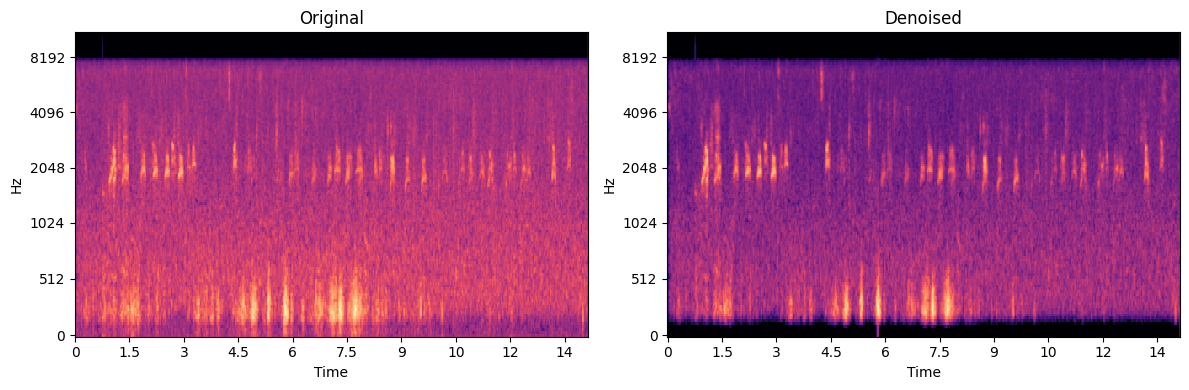

In [78]:
y, _ = librosa.load( "/automathon/users/mig_user3/Automathon_Sujet/dataset/processed_bird_songs/#eubeat1/XC56698.wav", sr=sr)
y2 , sr = librosa.load( "/automathon/users/mig_user3/Automathon_Sujet/dataset/cleaned_bird_songs/#eubeat1/XC56698.wav", sr=sr)
plot_comparison(y, y2, sr )

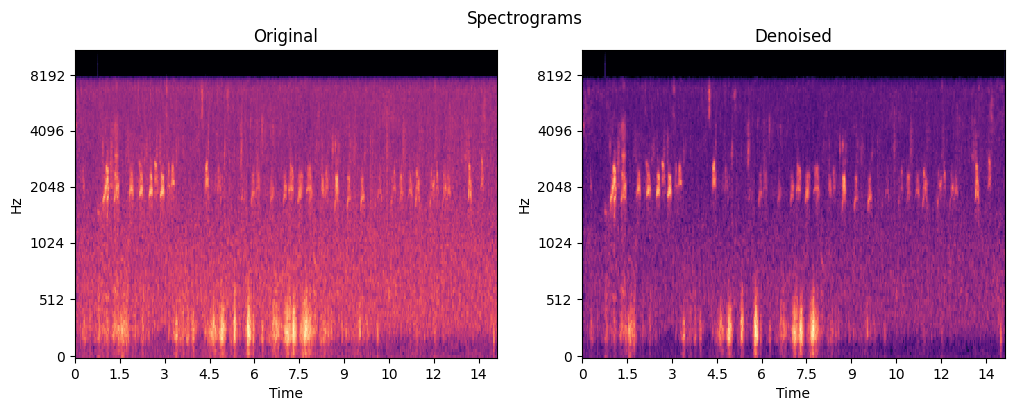

In [81]:
import librosa
import librosa.display
import noisereduce as nr
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf

# -----------------------------
# CONFIG
# -----------------------------
AUDIO_PATH = "/automathon/users/mig_user3/Automathon_Sujet/dataset/processed_bird_songs/#eubeat1/XC56698.wav"      # Replace with your audio file
OUTPUT_PATH = "/automathon/users/mig_user3/Automathon_Sujet/dataset/samplee_bird_clean.wav"
SAMPLE_RATE = 22050
N_FFT = 2048
HOP_LENGTH = 512
N_MELS = 128
PROP_DECREASE = 0.8               # Noise reduction aggressiveness

# -----------------------------
# SIGNAL UTILITIES
# -----------------------------
def estimate_noise(y, sr):
    """Estimate noise from lowest-energy 2% of frames."""
    frame_len = sr // 10  # 0.1 sec
    energy = np.convolve(y**2, np.ones(frame_len), mode="same")
    n = len(energy)
    low_idx = np.argpartition(energy, int(0.02 * n))[: int(0.02 * n)]
    start, end = low_idx.min(), low_idx.max()
    return y[start:end]

def plot_spectrograms(y_orig, y_clean, sr, title="Spectrograms"):
    """Plot Mel spectrograms of original and cleaned audio."""
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    S_orig = librosa.power_to_db(
        librosa.feature.melspectrogram(y=y_orig, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS, power=2.0),
        ref=np.max
    )
    S_clean = librosa.power_to_db(
        librosa.feature.melspectrogram(y=y_clean, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS, power=2.0),
        ref=np.max
    )

    librosa.display.specshow(S_orig, sr=sr, x_axis="time", y_axis="mel", ax=ax[0])
    ax[0].set_title("Original")
    librosa.display.specshow(S_clean, sr=sr, x_axis="time", y_axis="mel", ax=ax[1])
    ax[1].set_title("Denoised")
    plt.suptitle(title)
    plt.show()

# -----------------------------
# MAIN PROCESS
# -----------------------------
y, sr = librosa.load(AUDIO_PATH, sr=SAMPLE_RATE)
#y_denoised, sr = librosa.load("/automathon/users/mig_user3/Automathon_Sujet/dataset/cleaned_bird_songs/#eubeat1/XC56698.wav" , sr=SAMPLE_RATE)
# Estimate noise segment
noise_clip = estimate_noise(y, sr)

# Reduce noise
y_denoised = nr.reduce_noise(
    y=y,
    sr=sr,
    y_noise=noise_clip,
    prop_decrease=PROP_DECREASE,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH
)

# Plot spectrograms
plot_spectrograms(y, y_denoised, sr)

# # Save cleaned audio
sf.write(OUTPUT_PATH, y_denoised, sr)
# print(f"Denoised audio saved to {OUTPUT_PATH}")


In [2]:
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, medfilt
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm

# ================= CONFIG =================
DATASET_DIR = "/automathon/users/mig_user3/Automathon_Sujet/dataset/cleaned_bird_songs"
OUTPUT_DIR = "/automathon/users/mig_user3/Automathon_Sujet/dataset/denoised_segments"
SAMPLE_RATE = 22050
HP_CUTOFF = 200.0
QUANTILE = 0.1
MEDIAN_KERNEL = 5
SILENCE_WINDOW = 1024
SILENCE_THRESH = 0.01
SEGMENT_LENGTH_SEC = 1.0
VISUALIZE = False
N_JOBS = 4
N_MELS = 32
# ==========================================

def highpass(signal, sr, cutoff=HP_CUTOFF, order=4):
    if cutoff <= 0:
        return signal
    b, a = butter(order, cutoff/(sr/2), btype='highpass')
    return filtfilt(b, a, signal)

def quantile_denoise(y, n_fft=2048, hop_length=512, quantile=QUANTILE, median_kernel=MEDIAN_KERNEL):
    S = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)
    magnitude, phase = np.abs(S), np.angle(S)
    noise_est = np.quantile(magnitude, quantile, axis=1)
    noise_est = medfilt(noise_est, kernel_size=median_kernel)[:, None]
    S_clean_mag = np.maximum(magnitude - noise_est, 0.0)
    S_clean = S_clean_mag * np.exp(1j * phase)
    y_clean = librosa.istft(S_clean, hop_length=hop_length)
    return y_clean

def detect_silence(y, window_len=SILENCE_WINDOW, threshold=SILENCE_THRESH):
    envelope = np.convolve(np.abs(y), np.ones(window_len)/window_len, mode='same')
    return envelope > threshold

def segment_audio(y, mask, sr, segment_length_sec=SEGMENT_LENGTH_SEC):
    segments = []
    current = []
    for i, keep in enumerate(mask):
        if keep:
            current.append(y[i])
        elif current:
            segments.append(np.array(current))
            current = []
    if current:
        segments.append(np.array(current))
    
    final_segments = []
    seg_len_samples = int(segment_length_sec * sr)
    for seg in segments:
        for start in range(0, len(seg), seg_len_samples):
            s = seg[start:start+seg_len_samples]
            if len(s) < seg_len_samples:
                s = np.pad(s, (0, seg_len_samples - len(s)))
            final_segments.append(s)
    return final_segments

def compute_mels(segments, sr, n_mels=N_MELS):
    mel_specs = []
    for seg in segments:
        S = librosa.feature.melspectrogram(y=seg, sr=sr, n_mels=n_mels, power=2.0)
        S_db = librosa.power_to_db(S, ref=np.max)
        mel_specs.append(S_db)
    return mel_specs

def save_segments(output_path, segments, mel_specs):
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    np.save(output_path, {
        'waveforms': segments,
        'mels': mel_specs
    })

def process_file(input_path):
    try:
        y, sr = librosa.load(input_path, sr=SAMPLE_RATE)
        y = highpass(y, sr)
        y_denoised = quantile_denoise(y)
        mask = detect_silence(y_denoised)
        segments = segment_audio(y_denoised, mask, sr)
        mel_specs = compute_mels(segments, sr)

        # preserve species folder
        rel_path = os.path.relpath(input_path, DATASET_DIR)
        output_file = os.path.join(OUTPUT_DIR, os.path.splitext(rel_path)[0] + "_clips.npy")
        save_segments(output_file, segments, mel_specs)

        return input_path, len(segments)
    except Exception as e:
        return input_path, f"ERROR: {e}"

def get_audio_files(root_dir):
    for subdir, _, files in os.walk(root_dir):
        for f in files:
            if f.lower().endswith(".wav"):
                yield os.path.join(subdir, f)

def main():
    audio_files = list(get_audio_files(DATASET_DIR))
    print(f"Found {len(audio_files)} files to process.")
    results = []
    with ProcessPoolExecutor(max_workers=N_JOBS) as executor:
        for res in tqdm(executor.map(process_file, audio_files), total=len(audio_files)):
            results.append(res)
    for path, status in results:
        print(path, status)

if __name__ == "__main__":
    main()


Found 3952 files to process.


100%|██████████| 3952/3952 [13:34<00:00,  4.85it/s] 


/automathon/users/mig_user3/Automathon_Sujet/dataset/cleaned_bird_songs/thrnig1/XC650411.wav 107
/automathon/users/mig_user3/Automathon_Sujet/dataset/cleaned_bird_songs/thrnig1/XC372477.wav 78
/automathon/users/mig_user3/Automathon_Sujet/dataset/cleaned_bird_songs/thrnig1/XC560270.wav 138
/automathon/users/mig_user3/Automathon_Sujet/dataset/cleaned_bird_songs/thrnig1/XC547966.wav 399
/automathon/users/mig_user3/Automathon_Sujet/dataset/cleaned_bird_songs/thrnig1/XC370955.wav 178
/automathon/users/mig_user3/Automathon_Sujet/dataset/cleaned_bird_songs/thrnig1/XC376998.wav 727
/automathon/users/mig_user3/Automathon_Sujet/dataset/cleaned_bird_songs/thrnig1/XC652516.wav 413
/automathon/users/mig_user3/Automathon_Sujet/dataset/cleaned_bird_songs/thrnig1/XC660591.wav 22
/automathon/users/mig_user3/Automathon_Sujet/dataset/cleaned_bird_songs/thrnig1/XC575229.wav 11
/automathon/users/mig_user3/Automathon_Sujet/dataset/cleaned_bird_songs/thrnig1/XC342535.wav 1374
/automathon/users/mig_user3/Auto

In [3]:
data = np.load("/automathon/users/mig_user3/Automathon_Sujet/dataset/denoised_segments/barswa/XC46803_clips.npy", allow_pickle=True).item()
segments = data['waveforms']
mel_specs = data['mels']


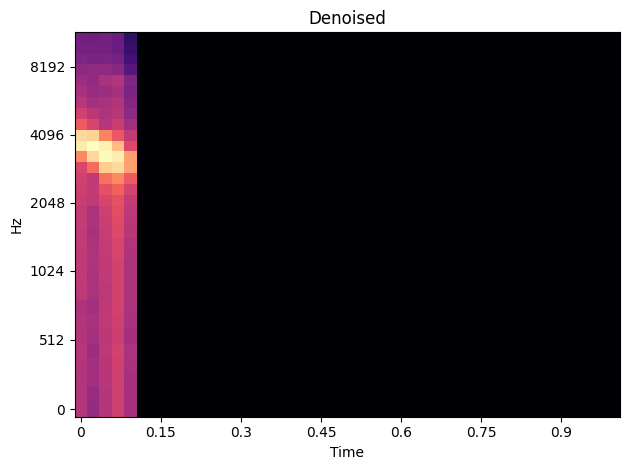

In [10]:
librosa.display.specshow(mel_specs[0], sr=22050, x_axis='time', y_axis='mel')
plt.title("Denoised")

plt.tight_layout()
plt.show()

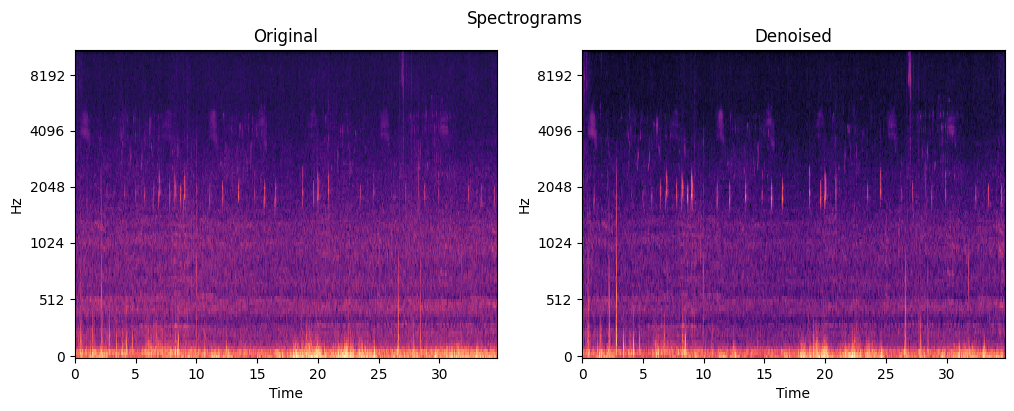

In [49]:
import librosa
import librosa.display
import noisereduce as nr
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf

# -----------------------------
# CONFIG
# -----------------------------
AUDIO_PATH = "/automathon/users/mig_user3/Automathon_Sujet/dataset/processed_bird_songs/#eubeat1/XC178406.wav"      # Replace with your audio file
OUTPUT_PATH = "/automathon/users/mig_user3/Automathon_Sujet/dataset/samplee_bird_clean.wav"
SAMPLE_RATE = 22050
N_FFT = 2048
HOP_LENGTH = 512
N_MELS = 128
PROP_DECREASE = 0.75             # Noise reduction aggressiveness

# -----------------------------
# SIGNAL UTILITIES
# -----------------------------
def estimate_noise(y, sr):
    """Estimate noise from lowest-energy 2% of frames."""
    frame_len = sr // 10  # 0.1 sec
    energy = np.convolve(y**2, np.ones(frame_len), mode="same")
    n = len(energy)
    low_idx = np.argpartition(energy, int(0.02 * n))[: int(0.02 * n)]
    start, end = low_idx.min(), low_idx.max()
    return y[start:end]

def plot_spectrograms(y_orig, y_clean, sr, title="Spectrograms"):
    """Plot Mel spectrograms of original and cleaned audio."""
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    S_orig = librosa.power_to_db(
        librosa.feature.melspectrogram(y=y_orig, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS, power=2.0),
        ref=np.max
    )
    S_clean = librosa.power_to_db(
        librosa.feature.melspectrogram(y=y_clean, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS, power=2.0),
        ref=np.max
    )

    librosa.display.specshow(S_orig, sr=sr, x_axis="time", y_axis="mel", ax=ax[0])
    ax[0].set_title("Original")
    librosa.display.specshow(S_clean, sr=sr, x_axis="time", y_axis="mel", ax=ax[1])
    ax[1].set_title("Denoised")
    plt.suptitle(title)
    plt.show()

# -----------------------------
# MAIN PROCESS
# -----------------------------
y, sr = librosa.load(AUDIO_PATH, sr=SAMPLE_RATE)
#y_denoised, sr = librosa.load("/automathon/users/mig_user3/Automathon_Sujet/dataset/cleaned_bird_songs/#eubeat1/XC56698.wav" , sr=SAMPLE_RATE)
# Estimate noise segment
noise_clip = estimate_noise(y, sr)

# Reduce noise
y_denoised = nr.reduce_noise(
    y=y,
    sr=sr,
    y_noise=noise_clip,
    prop_decrease=PROP_DECREASE,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH
)

# Plot spectrograms
plot_spectrograms(y, y_denoised, sr)

# # Save cleaned audio
sf.write(OUTPUT_PATH, y_denoised, sr)
# print(f"Denoised audio saved to {OUTPUT_PATH}")


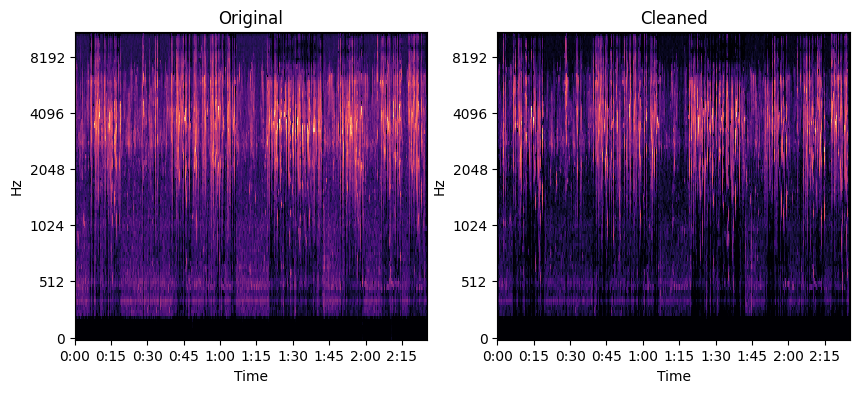

In [31]:
y, sr = librosa.load("/automathon/users/mig_user3/Automathon_Sujet/dataset/processed_bird_songs/barswa/XC141678.wav", sr=SAMPLE_RATE)
y1, sr = librosa.load("/automathon/users/mig_user3/Automathon_Sujet/dataset/cleaned_bird_songs/barswa/XC141678.wav", sr=SAMPLE_RATE)
plot_spectrograms(y, y1, sr, "")

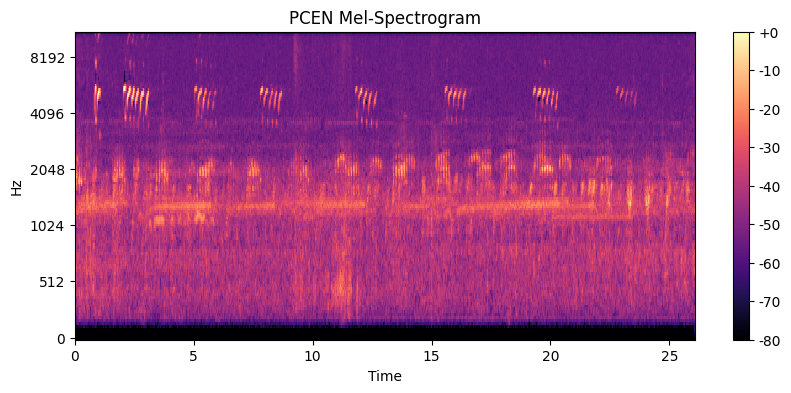

In [30]:
import librosa
import librosa.display
import numpy as np
# import matplotlib.pyplot as plt  # Optional for visualization

# --- 1. Load Audio ---
y, sr = librosa.load("/automathon/users/mig_user3/Automathon_Sujet/dataset/cleaned_bird_songs/comsan/XC183079.wav", sr=22050)

# --- 2. Compute Mel Spectrogram ---
N_FFT = 2048
HOP_LENGTH = 512
N_MELS = 128

# Compute Mel spectrogram directly from waveform
S_mel = librosa.power_to_db(
    librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=2048,
        hop_length=512,
        n_mels=128,
        power=2.0
    ),
    ref=np.max
)



# --- 3. Apply PCEN ---
# PCEN expects an amplitude (not dB or power) Mel spectrogram.
# Scaling up (×2**31) helps numerical stability on quiet recordings.
# pcen_S = librosa.pcen(
#     S_mel * (2**31),
#     sr=sr,
#     hop_length=HOP_LENGTH,
#     time_constant=0.06,  # T (smoothing time constant)
#     gain=0.98,           # alpha (AGC strength)
#     bias=2.0,            # delta (bias offset)
#     power=0.5,           # r (compression exponent)
#     eps=1e-6             # epsilon (stability term)
# )

# --- 4. Optional: Convert to "dB-like" scale for plotting ---
# Not required for models, but helpful for visual inspection.
# pcen_S_db = librosa.power_to_db(pcen_S, ref=np.max)

# --- 5. (Optional) Visualize ---
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
librosa.display.specshow(S_mel, sr=sr, hop_length=HOP_LENGTH, x_axis='time', y_axis='mel')
plt.title('PCEN Mel-Spectrogram')
plt.colorbar(format='%+2.0f')
plt.show()


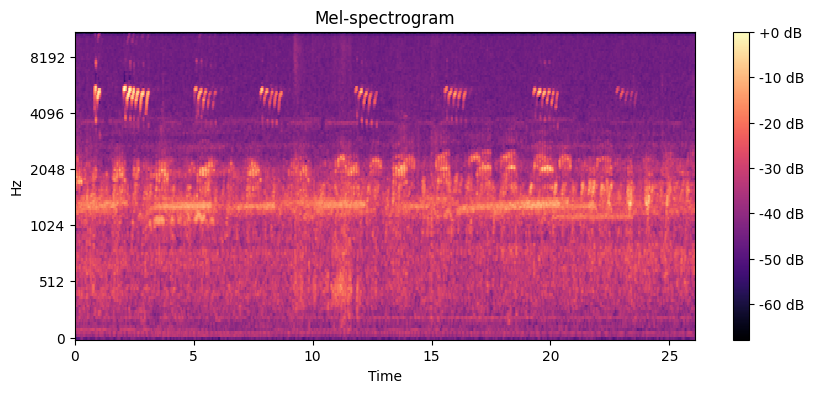

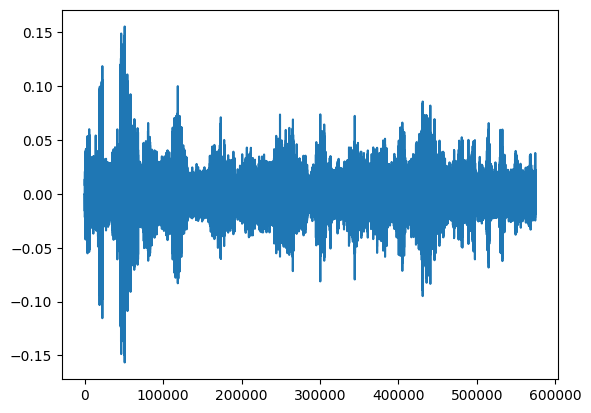

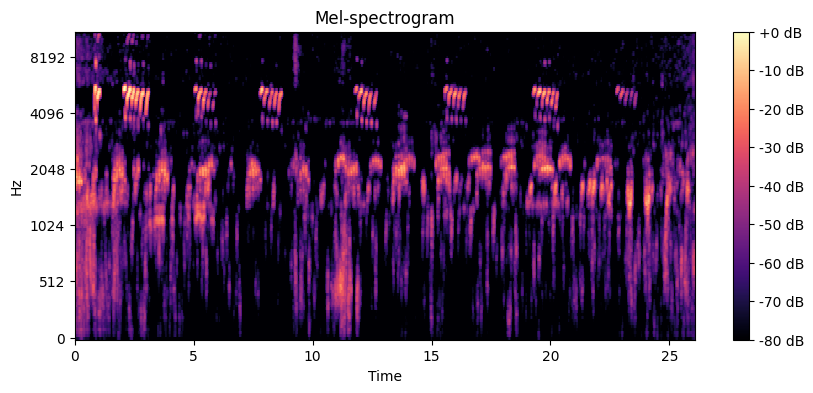

In [39]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter
import noisereduce as nr

file_path = "/automathon/users/mig_user3/Automathon_Sujet/dataset/processed_bird_songs/comsan/XC183079.wav"
target_sr = 22050
n_fft = 2048
hop_length = 512
n_mels = 128

y, sr = librosa.load(file_path, sr=target_sr)

def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def bandpass_filter(data, lowcut, highcut, fs, order=5):
    b, a = butter(order, [lowcut, highcut], btype='band', fs=fs)
    y = lfilter(b, a, data)
    return y

def compute_mel_spectrogram(y, sr, n_fft=4096, hop_length=512, n_mels=128):
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)
    S_db = librosa.power_to_db(S, ref=np.max)
    return S_db

lowcut = 500      # Hz
highcut = 10000 
S_db = compute_mel_spectrogram(y, sr)
# Visualize
plt.figure(figsize=(10, 4))
librosa.display.specshow(S_db, sr=sr, hop_length=hop_length, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title("Mel-spectrogram")
plt.show()
plt.plot(y)
#y = bandpass_filter(y, lowcut, highcut, sr)

# Denoise with spectral gating
y = nr.reduce_noise(y=y, sr=sr)

S_db = compute_mel_spectrogram(y, sr)
# Visualize
plt.figure(figsize=(10, 4))
librosa.display.specshow(S_db, sr=sr, hop_length=hop_length, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title("Mel-spectrogram")
plt.show()

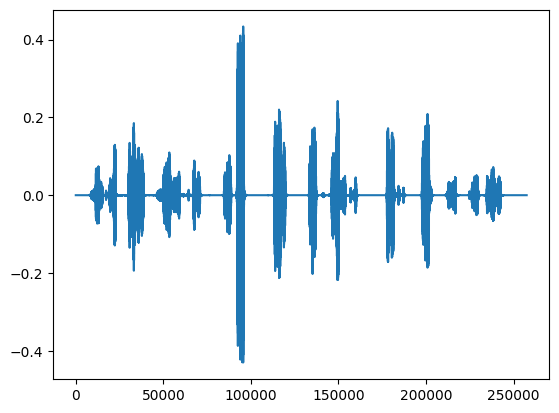

In [38]:
plt.plot(y)

In [42]:
import os
import librosa
import numpy as np
import soundfile as sf
from tqdm import tqdm

input_dir = "/automathon/users/mig_user3/Automathon_Sujet/dataset/processed_bird_songs"
output_dir = "/automathon/users/mig_user3/Automathon_Sujet/dataset/mel_spectrograms_denoise"
target_sr = 22050        # resample
n_fft = 2048             # FFT window size
hop_length = 512         # step between frames
n_mels = 128             # number of Mel bands

os.makedirs(output_dir, exist_ok=True)

def compute_mel_spectrogram(y, sr=22050, n_fft=2048, hop_length=512, n_mels=128):
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)
    S_db = librosa.power_to_db(S, ref=np.max) 
    return S_db


all_species = os.listdir(input_dir)
for species in tqdm(all_species, desc="Processing Species"): # <--- Added tqdm
    print(species)
    species_path = os.path.join(input_dir, species)
    if not os.path.isdir(species_path):
        continue

    out_species_dir = os.path.join(output_dir, species)
    os.makedirs(out_species_dir, exist_ok=True)
    all_files = os.listdir(species_path)
    audio_files = [f for f in all_files if f.endswith(".wav")]
    for filename in tqdm(audio_files, desc=f"  Files in {species}", leave=False): 
        file_path = os.path.join(species_path, filename)
        mel_out_file = os.path.join(out_species_dir, os.path.splitext(filename)[0] + ".npy")

        # Compute Mel-spectrogram
        y, sr = librosa.load(file_path, sr=target_sr)
        y = nr.reduce_noise(y=y, sr=sr) 
        S_db = compute_mel_spectrogram(y, sr=target_sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels) 

        # Save as .npy
        np.save(mel_out_file, S_db)

print("Mel-spectrograms computed and saved for all audios.")

Processing Species:   0%|          | 0/10 [00:00<?, ?it/s]

thrnig1


Processing Species:   0%|          | 0/10 [00:07<?, ?it/s]


KeyboardInterrupt: 

311617


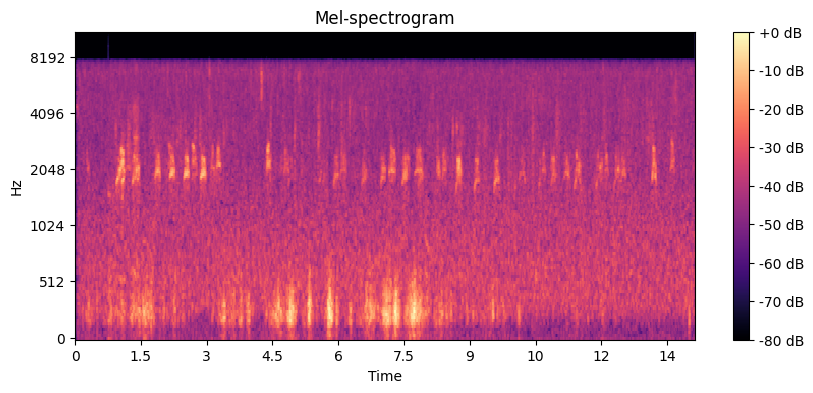

Total segments: 7


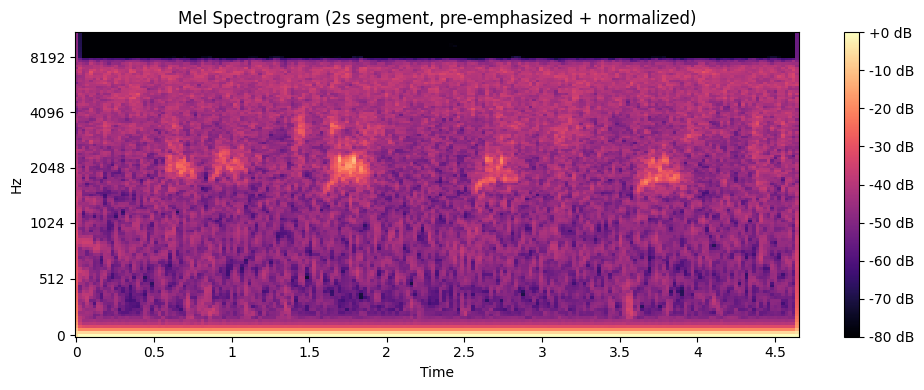

In [65]:
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import soundfile as sf

# ------------------------------
# Parameters
# ------------------------------
sr = 22050
segment_duration = 2.0  # seconds
pre_emphasis = 0.97
frame_length = 0.025  # 25 ms
frame_step = 0.010    # 10 ms
n_fft = 2048
n_mels = 128

input_file = "/automathon/users/mig_user3/Automathon_Sujet/dataset/processed_bird_songs/#eubeat1/XC56698.wav"


y, sr = librosa.load(input_file, sr=sr)
print(len(y))
S_db = compute_mel_spectrogram(y, sr)
# Visualize
plt.figure(figsize=(10, 4))
librosa.display.specshow(S_db, sr=sr, hop_length=hop_length, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title("Mel-spectrogram")
plt.show()
# ------------------------------
# Step 2: Segment into 2s chunks
# ------------------------------
segment_len = int(segment_duration * sr)
segments = [y[i:i+segment_len] for i in range(0, len(y), segment_len)]
segments = [seg for seg in segments if len(seg) == segment_len]  # drop incomplete

print(f"Total segments: {len(segments)}")

# ------------------------------
# Step 3: Apply pre-emphasis + normalization
# ------------------------------
def preprocess_segment(seg):
    # Pre-emphasis filter
    seg = np.append(seg[0], seg[1:] - pre_emphasis * seg[:-1])
    
    # Min–max normalization
    seg = (seg - np.min(seg)) / (np.max(seg) - np.min(seg) + 1e-8)
    return seg

segments = [preprocess_segment(seg) for seg in segments]

# ------------------------------
# Step 4: Compute Mel-spectrograms
# ------------------------------
def segment_to_mel(seg, sr, n_fft, n_mels, frame_length, frame_step):
    hop_length = int(frame_step * sr)
    win_length = int(frame_length * sr)
    S = librosa.feature.melspectrogram(
        y=seg, sr=sr, n_fft=n_fft, hop_length=hop_length, win_length=win_length,
        n_mels=n_mels
    )
    S_db = librosa.power_to_db(S, ref=np.max)
    return S_db

mel_segments = [segment_to_mel(seg, sr, n_fft, n_mels, frame_length, frame_step) for seg in segments]

# ------------------------------
# Step 5: Visualize one segment
# ------------------------------
plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_segments[4], sr=sr, x_axis='time', y_axis='mel')
plt.title("Mel Spectrogram (2s segment, pre-emphasized + normalized)")
plt.colorbar(format="%+2.0f dB")
plt.tight_layout()
plt.show()


Total segments: 10
f: 0.0020938609


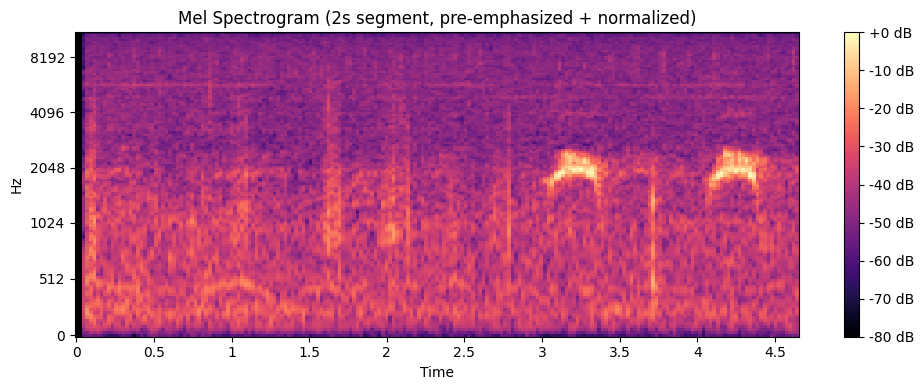

f: 0.00022258858


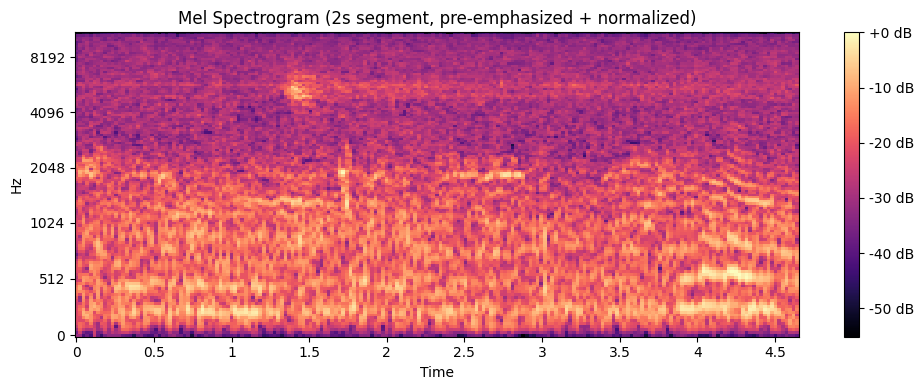

f: 0.00018408161


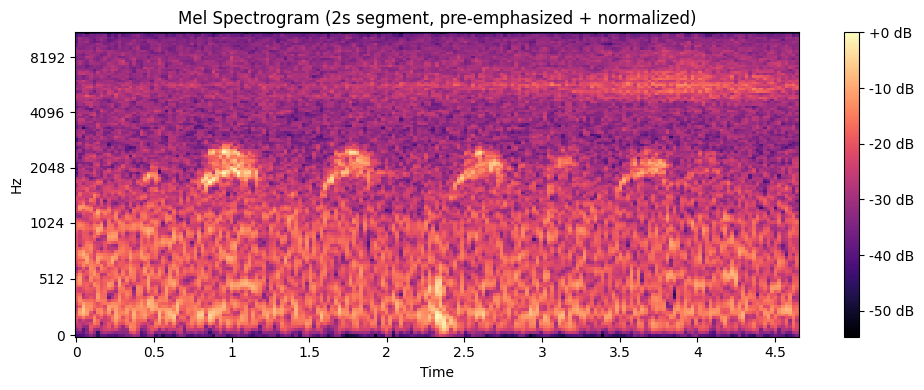

f: 0.0015053906


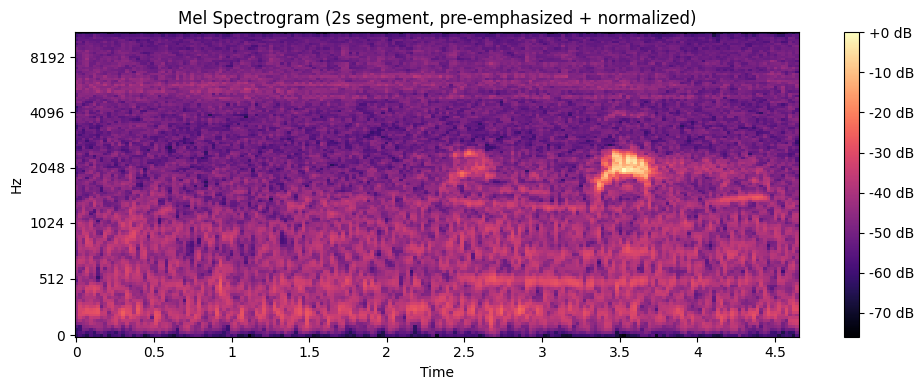

f: 0.00021240996


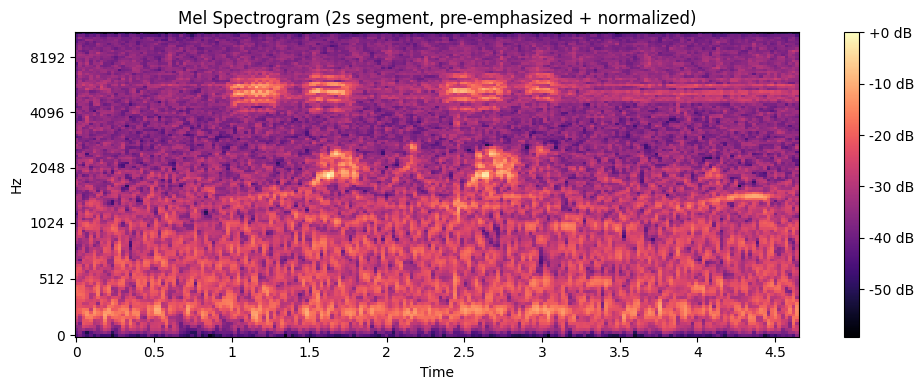

f: 0.00011881046


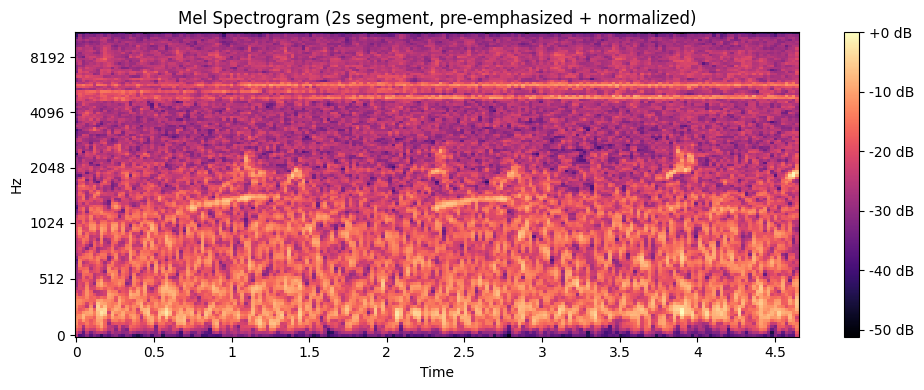

f: 0.0004538745


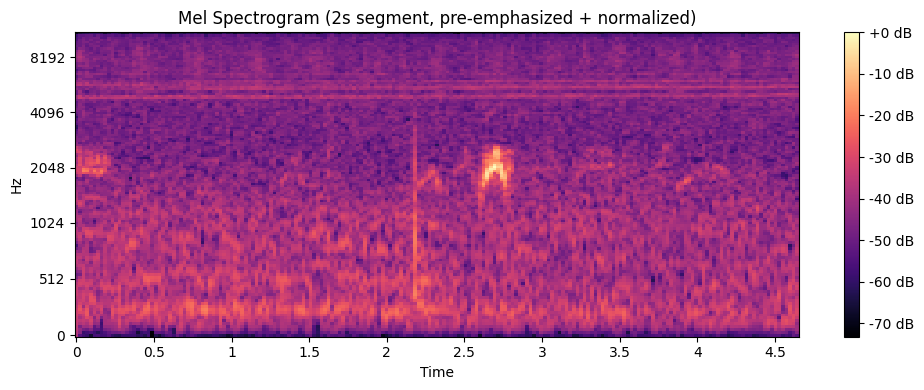

f: 0.00010518953


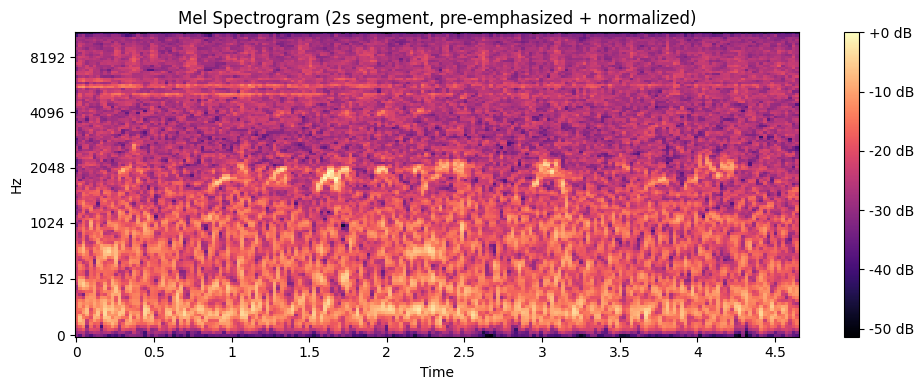

f: 9.6553915e-05


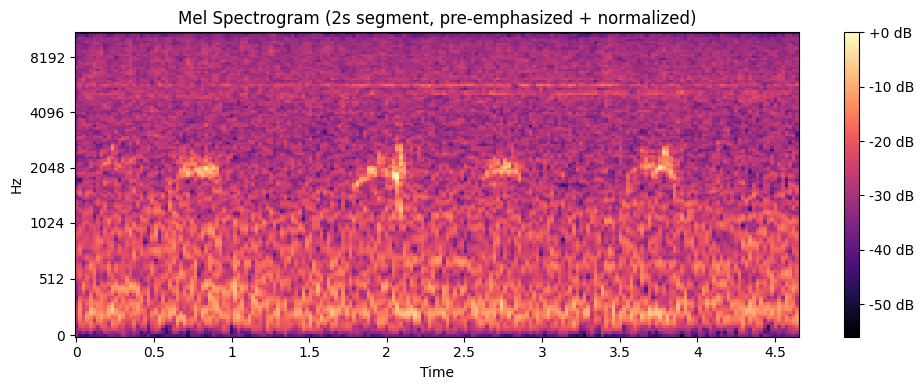

f: 0.0008117917


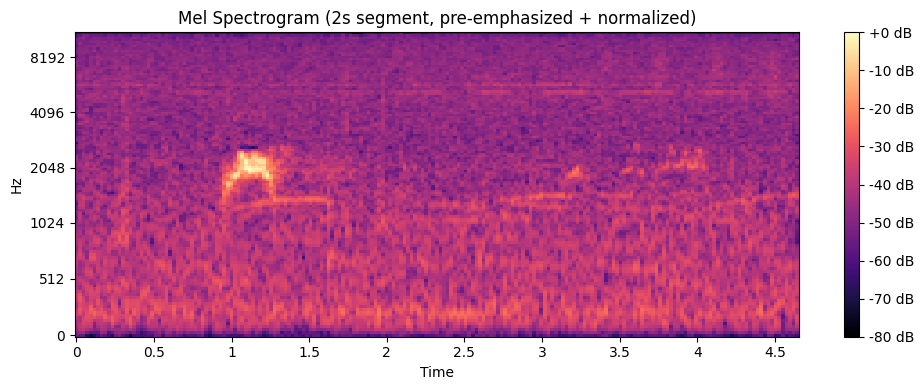

In [72]:
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import soundfile as sf

# ------------------------------
# Parameters
# ------------------------------
sr = 22050
segment_duration = 2.0  # seconds
pre_emphasis = 0.97
frame_length = 0.025  # 25 ms
frame_step = 0.010    # 10 ms
n_fft = 2048
n_mels = 128

input_file = "/automathon/users/mig_user3/Automathon_Sujet/dataset/processed_bird_songs/#eubeat1/XC126210.wav"


y, sr = librosa.load(input_file, sr=sr)

segment_len = int(segment_duration * sr)
segments = [y[i:i+segment_len] for i in range(0, len(y), segment_len)]
segments = [seg for seg in segments if len(seg) == segment_len]  # drop incomplete

print(f"Total segments: {len(segments)}")


# ------------------------------
# Step 4: Compute Mel-spectrograms
# ------------------------------
def segment_to_mel(seg, sr, n_fft, n_mels, frame_length, frame_step):
    hop_length = int(frame_step * sr)
    win_length = int(frame_length * sr)
    S = librosa.feature.melspectrogram(
        y=seg, sr=sr, n_fft=n_fft, hop_length=hop_length, win_length=win_length,
        n_mels=n_mels
    )
    S_db = librosa.power_to_db(S, ref=np.max)
    return S_db

mel_segments = [segment_to_mel(seg, sr, n_fft, n_mels, frame_length, frame_step) for seg in segments]
squares = [np.mean(np.square(seg)) for seg in segments]
# ------------------------------
# Step 5: Visualize one segment
# ------------------------------
for i in range(len(segments)):
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mel_segments[i], sr=sr, x_axis='time', y_axis='mel')
    print('f:', squares[i])
    plt.title("Mel Spectrogram (2s segment, pre-emphasized + normalized)")
    plt.colorbar(format="%+2.0f dB")
    plt.tight_layout()
    plt.show()

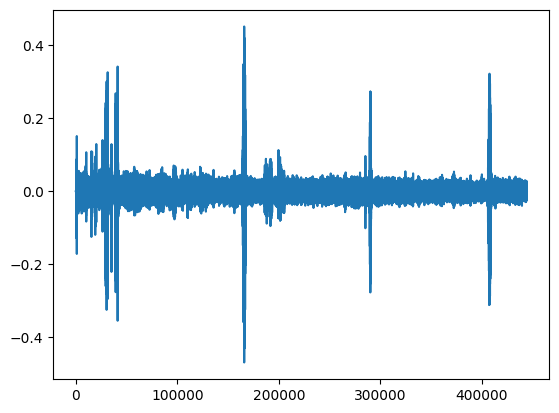

In [70]:
plt.plot(y)

In [66]:
segments[0]

array([0.48308524, 0.48303193, 0.48313695, ..., 0.43596667, 0.3547132 ,
       0.48341742], shape=(44100,), dtype=float32)

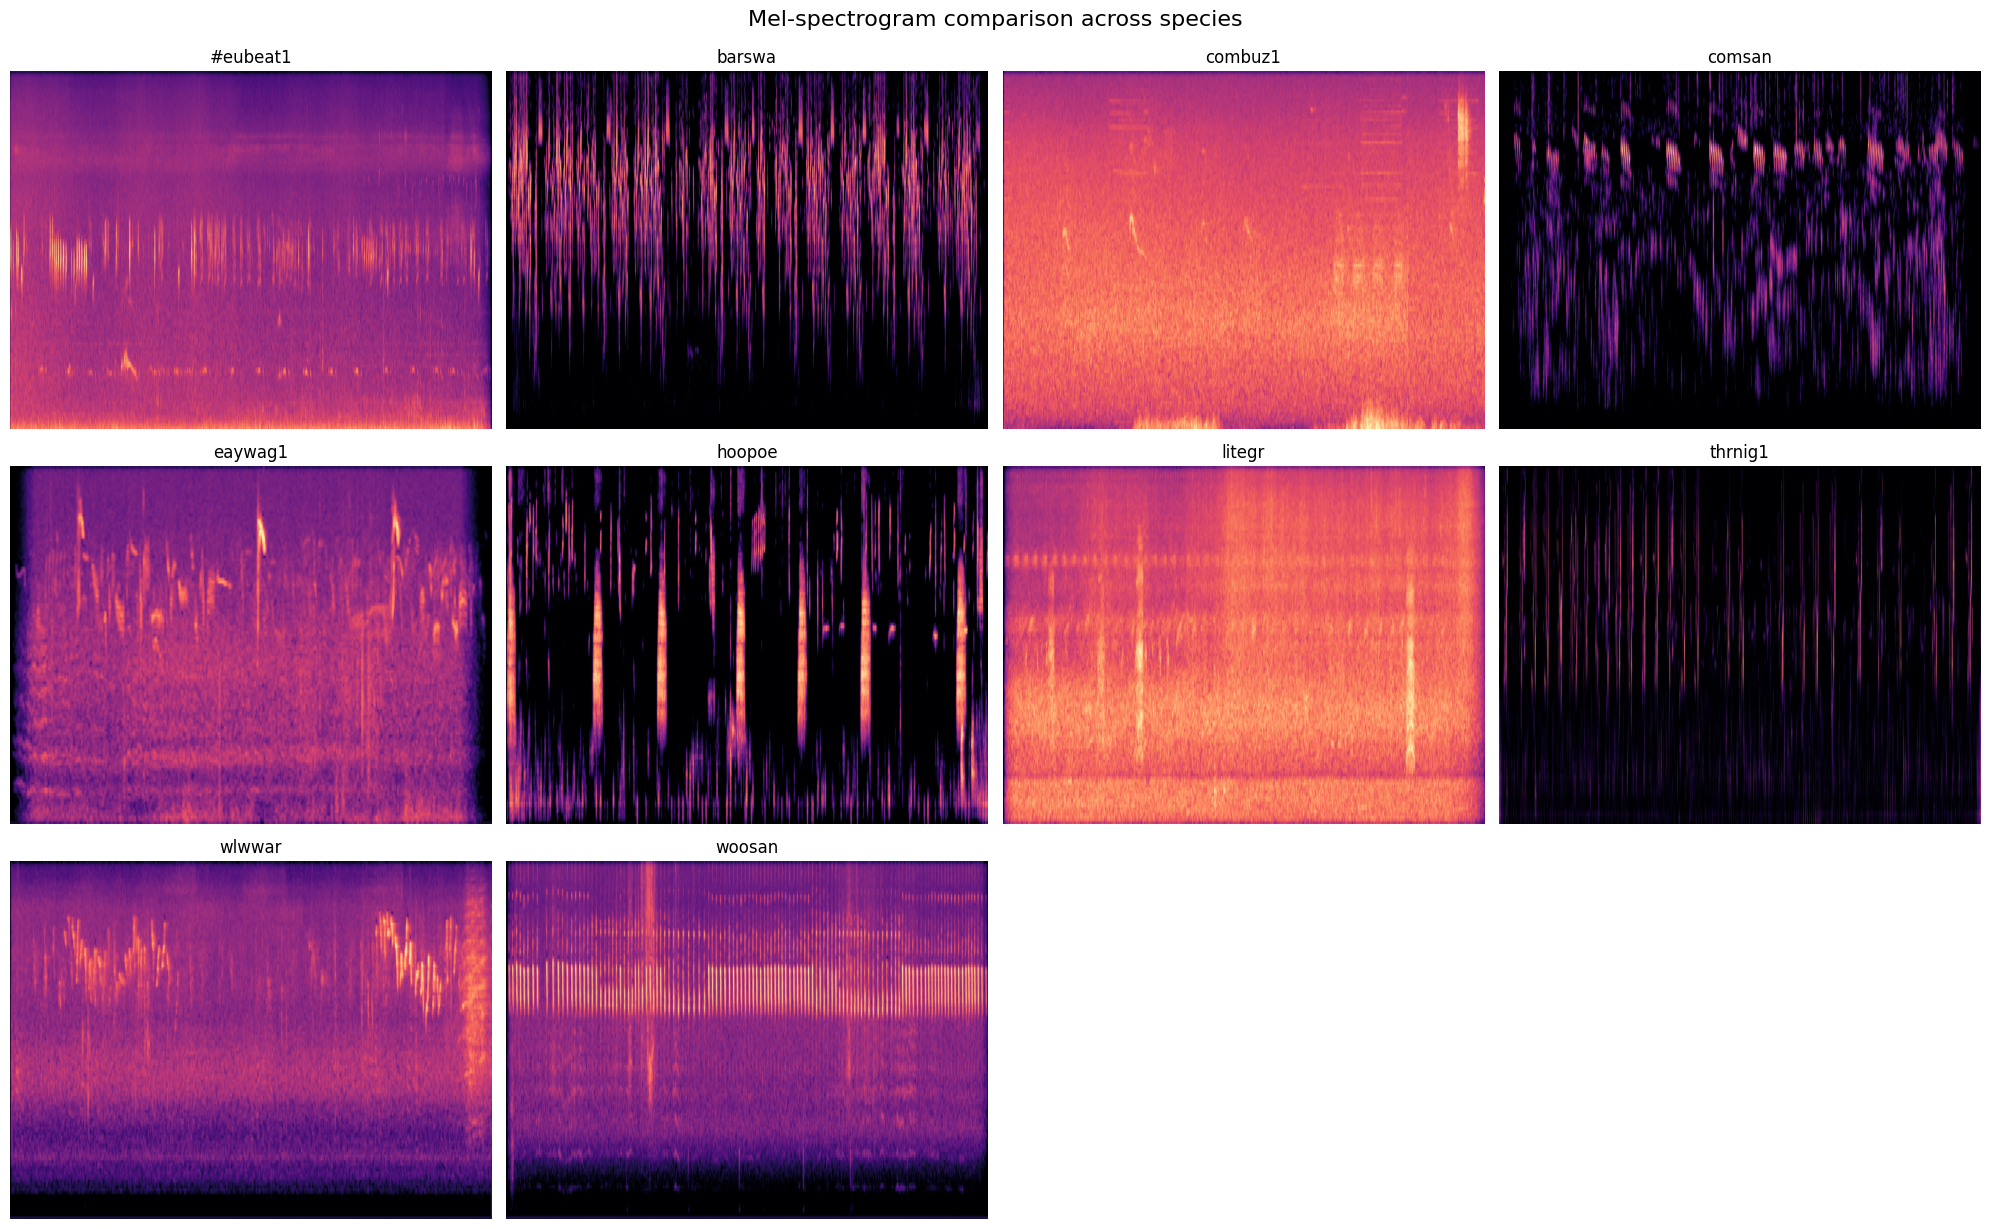

In [63]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# Paths
mel_dir = "/automathon/users/mig_user3/Automathon_Sujet/dataset/mel_spectrograms"

# List species (subfolders)
species_list = sorted([s for s in os.listdir(mel_dir) if os.path.isdir(os.path.join(mel_dir, s))])

# Prepare figure
n_species = len(species_list)
cols = min(n_species, 4)
rows = (n_species + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = np.array(axes).reshape(rows, cols)

for i, species in enumerate(species_list):
    species_path = os.path.join(mel_dir, species)
    npy_files = [f for f in os.listdir(species_path) if f.endswith(".npy")]
    if not npy_files:
        continue

    # Pick random file
    sample_file = random.choice(npy_files)
    S_db = np.load(os.path.join(species_path, sample_file))

    # Plot
    ax = axes.flat[i]
    img = ax.imshow(S_db, origin='lower', aspect='auto', cmap='magma')
    ax.set_title(species, fontsize=12)
    ax.axis('off')

# Remove empty subplots
for j in range(i + 1, rows * cols):
    fig.delaxes(axes.flat[j])

plt.tight_layout()
plt.suptitle("Mel-spectrogram comparison across species", fontsize=16, y=1.02)
plt.show()


In [ ]:
import os
import librosa
import numpy as np
import soundfile as sf
from scipy.signal import butter, lfilter
import noisereduce as nr

# ------------------------------
# Settings
# ------------------------------
input_dir = "/automathon/users/mig_user3/Automathon_Sujet/dataset/processed_bird_songs"
output_dir = "/automathon/users/mig_user3/Automathon_Sujet/dataset/mel_spectrograms_denoised"
target_sr = 22050
n_fft = 2048
hop_length = 512
n_mels = 128
lowcut = 500      # Hz
highcut = 12000   # Hz

os.makedirs(output_dir, exist_ok=True)

# ------------------------------
# Helper functions
# ------------------------------
def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def bandpass_filter(data, lowcut, highcut, fs, order=5):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = lfilter(b, a, data)
    return y

def compute_mel_spectrogram(y, sr, n_fft=2048, hop_length=512, n_mels=128):
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)
    S_db = librosa.power_to_db(S, ref=np.max)
    return S_db

# ------------------------------
# Process all audios
# ------------------------------
for species in os.listdir(input_dir):
    species_path = os.path.join(input_dir, species)
    if not os.path.isdir(species_path):
        continue

    out_species_dir = os.path.join(output_dir, species)
    os.makedirs(out_species_dir, exist_ok=True)

    for filename in os.listdir(species_path):
        if filename.endswith(".wav"):
            file_path = os.path.join(species_path, filename)
            mel_out_file = os.path.join(out_species_dir, os.path.splitext(filename)[0] + ".npy")

            # Load audio
            y, sr = librosa.load(file_path, sr=target_sr)

            # Band-pass filter
            y = bandpass_filter(y, lowcut, highcut, sr)

            # Denoise with spectral gating
            y = nr.reduce_noise(y=y, sr=sr)

            # Compute Mel-spectrogram
            S_db = compute_mel_spectrogram(y, sr, n_fft, hop_length, n_mels)

            # Save Mel-spectrogram
            np.save(mel_out_file, S_db)

print("All bird audios denoised and Mel-spectrograms saved.")


/automathon/users/mig_user3/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ValueError: Digital filter critical frequencies must be 0 < Wn < 1

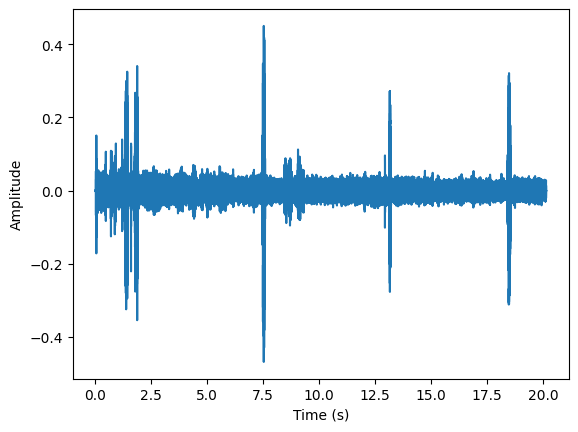

In [73]:
import numpy as np
# file_path = "/automathon/users/mig_user3/Automathon_Sujet/dataset/processed_bird_songs/barswa/XC169360.wav"
# target_sr = 22050
# n_fft = 2048
# hop_length = 512
# n_mels = 128

# y, sr = librosa.load(file_path, sr=target_sr)
time = np.arange(len(y)) / sr
plt.plot(time, y)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()
